# Prepare Render-Safe 2D Asset Bank

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import display
from PIL import Image
import matplotlib.pyplot as plt

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'backend').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate project root.')

PROJECT_ROOT = find_project_root()
BACKEND_ROOT = PROJECT_ROOT / 'backend'
if str(BACKEND_ROOT) not in sys.path:
    sys.path.append(str(BACKEND_ROOT))

from systems.static_auto_tryon.auto_app.ml.celeba_hair_rich import (
    enrich_render_safe_assets,
    load_extracted_asset_metadata,
    render_safe_summary,
    write_jsonl,
    write_review_csv,
)

PROJECT_ROOT

WindowsPath('.')

In [2]:
ASSET_ROOT = BACKEND_ROOT / 'data' / 'processed' / 'celeba_full_hair_assets'
METADATA_ROOT = ASSET_ROOT / 'metadata'
REVIEW_ROOT = ASSET_ROOT / 'review'
RENDER_SAFE_JSONL = REVIEW_ROOT / 'render_safe_candidates.jsonl'
RENDER_SAFE_CSV = REVIEW_ROOT / 'render_safe_candidates.csv'
RENDER_SAFE_REVIEW_CSV = REVIEW_ROOT / 'render_safe_review_template.csv'
RENDER_SAFE_SUMMARY_JSON = REVIEW_ROOT / 'render_safe_summary.json'

ASSET_ROOT

WindowsPath('./backend/data/processed/celeba_full_hair_assets')

In [3]:
metadata_rows = load_extracted_asset_metadata(METADATA_ROOT)
enriched_rows = enrich_render_safe_assets(metadata_rows)
candidate_rows = [row for row in enriched_rows if row.get('render_safe_candidate')]
summary = render_safe_summary(metadata_rows)

print('Total assets:', len(metadata_rows))
print('Render-safe candidates:', len(candidate_rows))
summary

Total assets: 209
Render-safe candidates: 157


{'total_assets': 209,
 'render_safe_candidates': 157,
 'accepted_ratio': 0.7512,
 'avg_render_safe_score': 0.9167,
 'flag_counts': {'render_safe_candidate': 157,
  'asymmetric_side_mass': 28,
  'low_full_hair_score': 25,
  'not_high_confidence': 14,
  'short_mask': 12,
  'narrow_mask': 7,
  'high_coverage': 2,
  'heavy_outer_side_mass': 1}}

In [4]:
frame = pd.DataFrame([
    {
        'asset_id': row['asset_id'],
        'partition': row.get('partition'),
        'gender_label': row.get('gender_label'),
        'confidence_bucket': row.get('confidence_bucket'),
        'quality_score': row.get('quality_score'),
        'full_hair_score': row.get('full_hair_score'),
        'render_safe_score': row.get('render_safe_score'),
        'coverage_ratio': row.get('hair_mask_stats', {}).get('coverage_ratio'),
        'bbox_width': row.get('hair_mask_stats', {}).get('bbox_width'),
        'bbox_height': row.get('hair_mask_stats', {}).get('bbox_height'),
        'crop_width': row.get('crop_size', {}).get('width'),
        'crop_height': row.get('crop_size', {}).get('height'),
        'render_safe_candidate': row.get('render_safe_candidate'),
        'render_safe_flags': ', '.join(row.get('render_safe_flags', [])),
        'image_path': row.get('image_path'),
        'mask_path': row.get('mask_path'),
    }
    for row in enriched_rows
]).sort_values(['render_safe_candidate', 'render_safe_score', 'quality_score'], ascending=[False, False, False]).reset_index(drop=True)

display(frame.head(20))

,asset_id,partition,gender_label,confidence_bucket,quality_score,full_hair_score,render_safe_score,coverage_ratio,bbox_width,bbox_height,crop_width,crop_height,render_safe_candidate,render_safe_flags,image_path,mask_path
0,celeba_full_hair_000003,train,female,high,1.0,1.0,1.0,0.363416,136,208,174,218,True,render_safe_candidate,PROJECT_ROOT/...,PROJECT_ROOT/...
1,celeba_full_hair_000004,train,male,high,1.0,1.0,1.0,0.207968,143,129,165,152,True,render_safe_candidate,PROJECT_ROOT/...,PROJECT_ROOT/...
2,celeba_full_hair_000005,train,female,high,1.0,1.0,1.0,0.260927,135,193,169,218,True,render_safe_candidate,PROJECT_ROOT/...,PROJECT_ROOT/...
3,celeba_full_hair_000006,train,male,high,1.0,1.0,1.0,0.377049,147,194,172,217,True,render_safe_candidate,PROJECT_ROOT/...,PROJECT_ROOT/...
4,celeba_full_hair_000007,train,male,high,1.0,1.0,1.0,0.209076,123,141,161,157,True,render_safe_candidate,PROJECT_ROOT/...,PROJECT_ROOT/...
5,celeba_full_hair_000011,train,female,high,1.0,1.0,1.0,0.349990,170,204,178,218,True,render_safe_candidate,PROJECT_ROOT/...,PROJECT_ROOT/...
6,celeba_full_hair_000012,train,female,high,1.0,1.0,1.0,0.210777,134,159,173,185,True,render_safe_candidate,PROJECT_ROOT/...,PROJECT_ROOT/...
7,celeba_full_hair_000015,train,male,high,1.0,1.0,1.0,0.205391,118,165,154,185,True,render_safe_candidate,PROJECT_ROOT/...,PROJECT_ROOT/...
8,celeba_full_hair_000017,train,female,high,1.0,1.0,1.0,0.234048,129,208,165,218,True,render_safe_candidate,PROJECT_ROOT/...,PROJECT_ROOT/...
9,celeba_full_hair_000018,train,male,high,1.0,1.0,1.0,0.185393,119,167,157,194,True,render_safe_candidate,PROJECT_ROOT/...,PROJECT_ROOT/...


In [5]:
review_rows = []
for row in candidate_rows:
    review_rows.append({
        'asset_id': row['asset_id'],
        'image_path': row['image_path'],
        'mask_path': row['mask_path'],
        'partition': row.get('partition'),
        'gender_label': row.get('gender_label'),
        'confidence_bucket': row.get('confidence_bucket'),
        'quality_score': row.get('quality_score'),
        'full_hair_score': row.get('full_hair_score'),
        'render_safe_score': row.get('render_safe_score'),
        'render_keep': '',
        'render_notes': '',
    })

REVIEW_ROOT.mkdir(parents=True, exist_ok=True)
write_jsonl(candidate_rows, RENDER_SAFE_JSONL)
frame[frame['render_safe_candidate']].to_csv(RENDER_SAFE_CSV, index=False, encoding='utf-8')
write_review_csv(review_rows, RENDER_SAFE_REVIEW_CSV)
RENDER_SAFE_SUMMARY_JSON.write_text(json.dumps(summary, indent=2), encoding='utf-8')

print('Wrote:', RENDER_SAFE_JSONL)
print('Wrote:', RENDER_SAFE_CSV)
print('Wrote:', RENDER_SAFE_REVIEW_CSV)
print('Wrote:', RENDER_SAFE_SUMMARY_JSON)

Wrote: backend/data\processed\celeba_full_hair_assets\review\render_safe_candidates.jsonl
Wrote: backend/data\processed\celeba_full_hair_assets\review\render_safe_candidates.csv
Wrote: backend/data\processed\celeba_full_hair_assets\review\render_safe_review_template.csv
Wrote: backend/data\processed\celeba_full_hair_assets\review\render_safe_summary.json


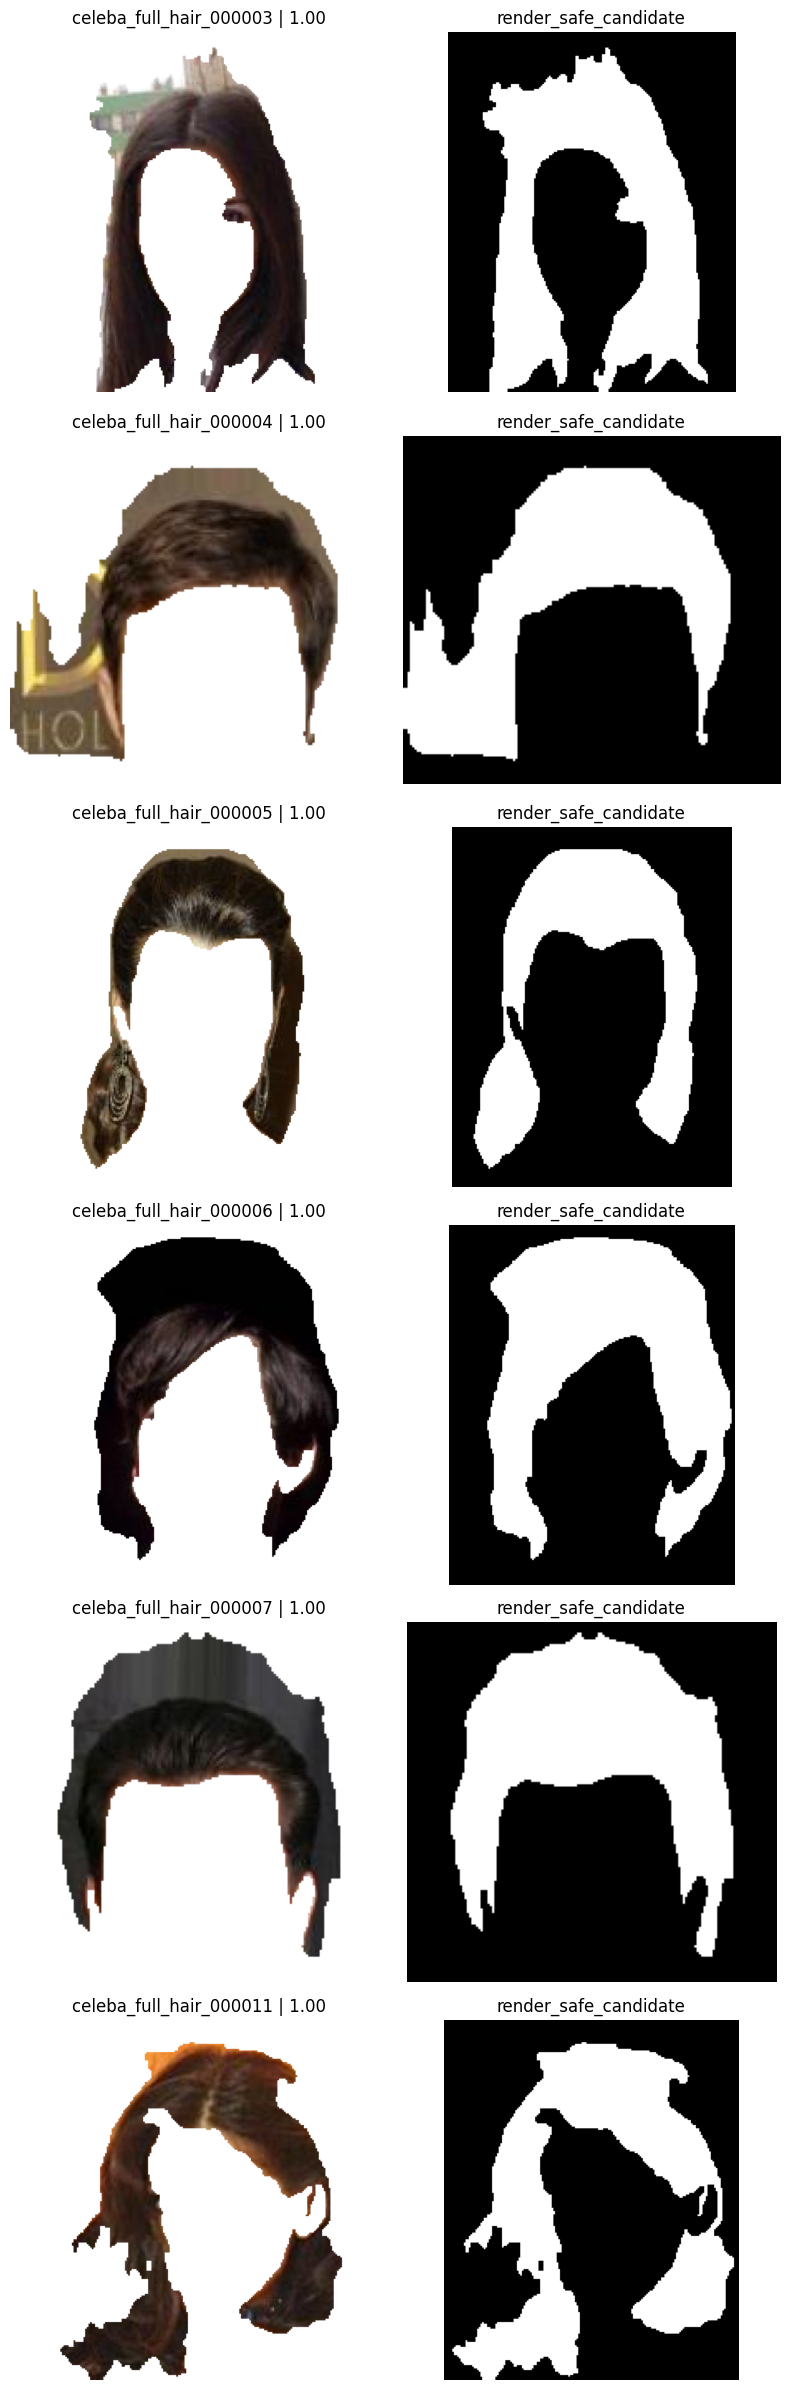

In [6]:
preview_rows = frame[frame['render_safe_candidate']].head(6).to_dict(orient='records')
if not preview_rows:
    print('No render-safe candidates to preview.')
else:
    fig, axes = plt.subplots(len(preview_rows), 2, figsize=(8, 4 * len(preview_rows)))
    if len(preview_rows) == 1:
        axes = [axes]

    for axis_pair, row in zip(axes, preview_rows):
        with Image.open(row['image_path']) as image:
            axis_pair[0].imshow(image.convert('RGBA'))
        axis_pair[0].set_title(f"{row['asset_id']} | {row['render_safe_score']:.2f}")
        axis_pair[0].axis('off')

        with Image.open(row['mask_path']) as mask:
            axis_pair[1].imshow(mask.convert('L'), cmap='gray')
        axis_pair[1].set_title(', '.join(flag for flag in row['render_safe_flags'].split(', ') if flag))
        axis_pair[1].axis('off')

    plt.tight_layout()